<img src="../images/cneos_header.gif" alt="Bay Area Fireball" width="600"></img>


[Bay Area Fireball, October 17, 2012](https://www.nasa.gov/image-article/bay-area-fireball-oct-17-2012/)

# NASA API: World Map of Fireball Impacts

---

## Overview
This notebook will cover all the steps to access bright meteor and fireball impact data collected by NASA's CNEOS and produce a global plot of impact sites

1. Prerequisites
2. CNEOS Overview
3. Imports
4. Access and Organize Data
5. Plot Earth Fireball Impacts
6. Summary

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Matplotlib](https://foundations.projectpythia.org/core/matplotlib/matplotlib-basics) | Necessary | Plotting on a data |
| [Intro to GeoPandas](https://geopandas.org/en/stable/) | Necessary | Plotting on a world map |
| [Intro to Pandas](https://foundations.projectpythia.org/core/pandas/pandas) | Necessary | Familiarity with working with dataframes |

---

## CNEOS Overivew

A shooting star is a common term for a meteor and form bright trails of light that are often bright enough to be visible during the day. A "fireball" is a term for expectionally bright meteor that enters the Earth's atmosphere at high speeds. A meteor that form fireballs can be over one meter long. A "bolide" typically refers to a fireball that breaks up in the atmosphere. These objects are tracked by the [Center for Near Earth Object Studies (CNEOS)](https://cneos.jpl.nasa.gov/) and information about the Peak Brightness, Velocity, and Joules of energy radiatated can be retrieved from CNEOS via an API

### Fireball Data API

This notebook will query the Fireball API for data from the last decade of observations

JPL's Center for Near-Earth Objects Studies [API "Fireball"](https://ssd-api.jpl.nasa.gov/doc/fireball.html) is an API that will return machine-readable data in the form of a JSON.

All queries to the Fireball Data API make requests to `https://ssd-api.jpl.nasa.gov/fireball.api`

The API accepts different query parameters to filter the data

Directly querying `https://ssd-api.jpl.nasa.gov/fireball.api` will return all the data of fireball impacts in reverse-chronological order

| Parameter | Type | Description |
| --- | --- | --- |
| date-min | string | exclude data earlier than this date `YYYY-MM-DD` or date/time `YYYY-MM-DDThh:mm:ss` |
| date-max | string | exclude data later than this date `YYYY-MM-DD` or date/time `YYYY-MM-DDThh:mm:ss` |
| energy-min | string | exclude data with total-radiated-energy less than this positive value in joules ×1010 (e.g., `0.3` = 0.3×1010 joules) |
| energy-max | string | exclude data with total-radiated-energy greater than this (see energy-min) |
| impact-e-min | string | exclude data with estimated impact energy less than this positive value in kilotons (kt) (e.g., `0.08` kt) |
| impact-e-max | string | exclude data with total-radiated-energy greater than this (see impact-e-min) |
| alt-min | number | exclude data from objects with an altitude less than this (e.g., `22` meaning objects smaller than this) |
| alt-max | number | exclude data from objects with an altitude greater than this (e.g., `17.75` meaning objects larger than this) |
| req-loc | boolean | location (latitude and longitude) required; when set `true`, exclude data without a location |
| req-alt | boolean | altitude required; when set `true`, exclude data without an altitude |
| req-vel-comp | boolean | pre-entry velocity components required; when set `true`, exclude data without pre-entry velocity components |
| vel-comp | boolean | include pre-entry velocity components |
| sort | string | sort data on the specified field: “date”, “energy”, “impact-e”, “vel”, or “alt” (default sort order is ascending: prepend “-“ for descending) |
| limit | number | limit data to the first N results (where N is the specified number and must be an integer value greater than zero) |

Results from API will be returned as JSON with a number of fields

| Field | Description |
| --- | --- |
| date | date/time of peak brightness (GMT) |
| lat | latitude at peak brightness (degrees) |
| lon | longitude at peak brightness (degrees) |
| lat-dir | latitude direction (“N” or “S”) |
| lon-dir | latitude direction (“E” or “W”) |
| alt | altitude above the geoid at peak brightness (km) |
| energy | approximate total radiated energy (10^10 joules) |
| impact-e | approximate total impact energy (kt) |
| vx | pre-entry velocity (Earth centered X component, km/s) |
| vy | pre-entry velocity (Earth centered Y component, km/s) | 
| vz | pre-entry velocity (Earth centered Z component, km/s) |

## Example JSON result

Return the last 3 records `https://ssd-api.jpl.nasa.gov/fireball.api?limit=3`

```
{
    "signature":
        {
            "version":"1.0",
            "source":"NASA/JPL Fireball Data API"
        },
    "count":"3",
    "fields":["date","energy","impact-e","lat","lat-dir","lon","lon-dir","alt","vel"],
    "data":[
        ["2024-06-03 01:13:51","2.6","0.092","63.1","S","53.2","W","60.0",null],
        ["2024-06-01 23:24:59","7.9","0.25","1.0","S","15.9","W","26.5","12.6"],
        ["2024-05-27 03:19:36","8.4","0.26","1.7","N","39.4","W","56.0","39.2"]
    ]
}
```

## Imports

In [1]:
import requests                  # submit API request query
import pandas as pd              # organizes data retrieved by the API
import geopandas                 # generate a world map
import matplotlib.pyplot as plt  # plotting data

## Request Fireball Data via API

To retrieve all the fireballs recorded in the last decade (2014-2024)

In [2]:
data_since = "2014-01-01"
last_decade_fireball = requests.get(f"https://ssd-api.jpl.nasa.gov/fireball.api?date-min={data_since}")
last_decade_fireball.status_code # 200 is a valid request

200

In [3]:
fireball_json = last_decade_fireball.json()

In [4]:
# print out data labels
print(f"fields = {fireball_json['fields']}")

fields = ['date', 'energy', 'impact-e', 'lat', 'lat-dir', 'lon', 'lon-dir', 'alt', 'vel']


In [5]:
# convert JSON data to a Pandas dataframe
fireball_df = pd.DataFrame(fireball_json["data"], columns=fireball_json["fields"])
fireball_df

,date,energy,impact-e,lat,lat-dir,lon,lon-dir,alt,vel
0,2026-03-17 12:56:42,12.6,0.37,41.2,N,82.0,W,43.5,12.3
1,2026-02-10 14:26:26,2.1,0.076,64.0,S,14.0,W,44.0,NaN
2,2026-01-31 18:07:14,5.8,0.19,4.1,N,173.4,W,32.0,NaN
3,2026-01-30 10:25:37,3.4,0.12,45.0,S,174.5,E,89.0,71.1
4,2025-12-16 20:58:12,9.6,0.29,24.1,S,92.4,W,25.0,19.0
...,...,...,...,...,...,...,...,...,...
437,2014-02-13 06:47:41,63,1.5,13.3,N,110.7,W,25.0,NaN
438,2014-01-19 02:54:38,14,0.41,66.1,S,74.6,E,NaN,NaN
439,2014-01-15 02:46:13,14,0.41,18.5,S,141.8,E,29.6,NaN
440,2014-01-12 16:00:48,7.8,0.24,2.9,N,64.4,E,37.0,16.2


In [6]:
# remove nan and duplicated data rows and reindex rows
fireball_df.dropna(inplace=True, ignore_index=True)

# convert columnss from strings to a float
fireball_df["energy"] = fireball_df["energy"].astype(float)
fireball_df["impact-e"] = fireball_df["impact-e"].astype(float)
fireball_df["lat"] = fireball_df["lat"].astype(float)
fireball_df["lon"] = fireball_df["lon"].astype(float)
fireball_df["alt"] = fireball_df["alt"].astype(float)
fireball_df["vel"] = fireball_df["vel"].astype(float)

# convert latitude to negative if lat-dir is S and longitude to negative if lon-dir is W
fireball_df['lat'] = fireball_df['lat'].mask(fireball_df['lat-dir'].eq('S'), -fireball_df['lat'])
fireball_df['lon'] = fireball_df['lon'].mask(fireball_df['lon-dir'].eq('W'), -fireball_df['lon'])

# rename columns
fireball_df = fireball_df.rename(columns= {"impact-e": "impact energy",
                                           "lat": "latitude",
                                           "lat-dir": "latitude direction",
                                           "lon": "longitude",
                                           "lon-dir": "longitude direction",
                                           "alt": "altitude",
                                           "vel": "velocity"})


fireball_df

,date,energy,impact energy,latitude,latitude direction,longitude,longitude direction,altitude,velocity
0,2026-03-17 12:56:42,12.60,0.37,41.2,N,-82.0,W,43.5,12.3
1,2026-01-30 10:25:37,3.40,0.12,-45.0,S,174.5,E,89.0,71.1
2,2025-12-16 20:58:12,9.60,0.29,-24.1,S,-92.4,W,25.0,19.0
3,2025-11-15 00:48:43,10.50,0.32,-62.2,S,-94.7,W,30.0,16.0
4,2025-11-11 17:39:51,9.30,0.28,27.3,N,-79.8,W,42.0,18.7
...,...,...,...,...,...,...,...,...,...
256,2014-05-16 12:42:47,35.10,0.92,-44.2,S,-176.2,W,44.0,16.5
257,2014-05-08 19:42:37,105.00,2.40,-36.9,S,87.3,E,35.4,19.0
258,2014-03-29 13:45:42,3.98,0.13,-28.7,S,121.5,E,30.7,16.3
259,2014-01-12 16:00:48,7.80,0.24,2.9,N,64.4,E,37.0,16.2


In [7]:
fireball_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 261 non-null    str    
 1   energy               261 non-null    float64
 2   impact energy        261 non-null    float64
 3   latitude             261 non-null    float64
 4   latitude direction   261 non-null    str    
 5   longitude            261 non-null    float64
 6   longitude direction  261 non-null    str    
 7   altitude             261 non-null    float64
 8   velocity             261 non-null    float64
dtypes: float64(6), str(3)
memory usage: 23.9 KB


### Plot the Energy of Fireballs

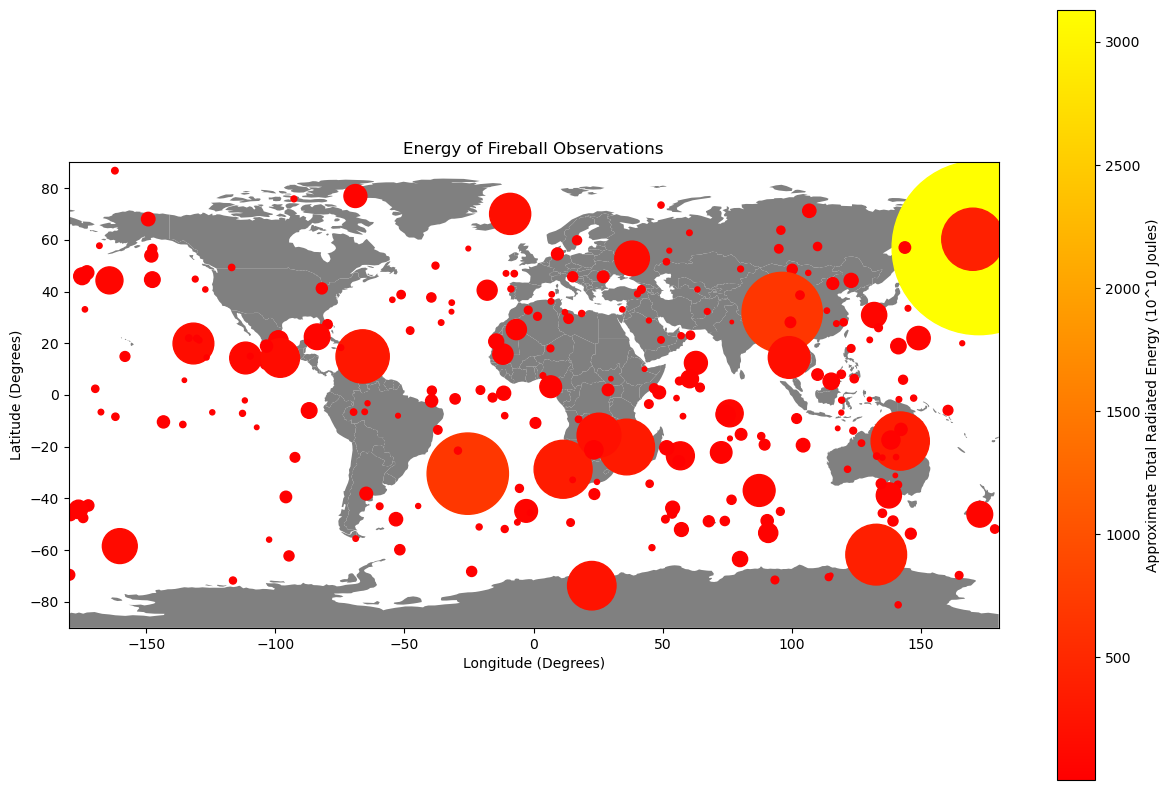

In [8]:
# retrieve world map from GeoPandas
world_map = geopandas.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# Set up world map plot
fig, ax = plt.subplots(figsize=(15, 10))
world_map.plot(color="grey", ax=ax)

# Plot Fireball Locations with Energy
x = fireball_df["longitude"]
y = fireball_df["latitude"]
z = fireball_df["energy"]
plt.scatter(x, y, s=5*z, c=z, cmap="autumn")
plt.colorbar(label="Approximate Total Radiated Energy (10^10 Joules)")

# Setup Axis Limits and Title/Labels
plt.xlim([-180, 180])
plt.ylim([-90, 90])
plt.title("Energy of Fireball Observations")
plt.xlabel("Longitude (Degrees)")
plt.ylabel("Latitude (Degrees)")
plt.show()

### Plot the Impact Energy of Fireballs

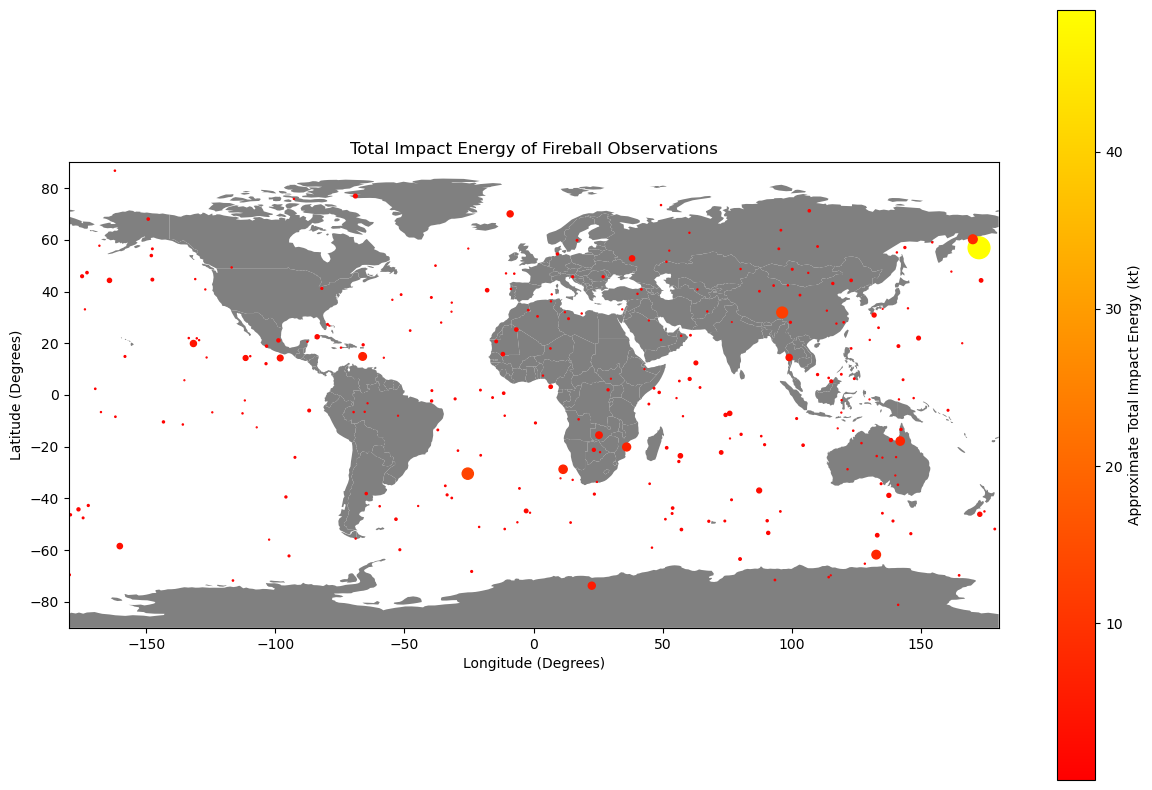

In [9]:
# retrieve world map from GeoPandas
world_map = geopandas.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# Set up world map plot
fig, ax = plt.subplots(figsize=(15, 10))
world_map.plot(color="grey", ax=ax)

# Plot Fireball Locations with Energy
x = fireball_df["longitude"]
y = fireball_df["latitude"]
z = fireball_df["impact energy"]
plt.scatter(x, y, s=5*z, c=z, cmap="autumn")
plt.colorbar(label="Approximate Total Impact Energy (kt)")

# Setup Axis Limits and Title/Labels
plt.xlim([-180, 180])
plt.ylim([-90, 90])
plt.title("Total Impact Energy of Fireball Observations")
plt.xlabel("Longitude (Degrees)")
plt.ylabel("Latitude (Degrees)")
plt.show()

### Plot the Velocity of Fireballs

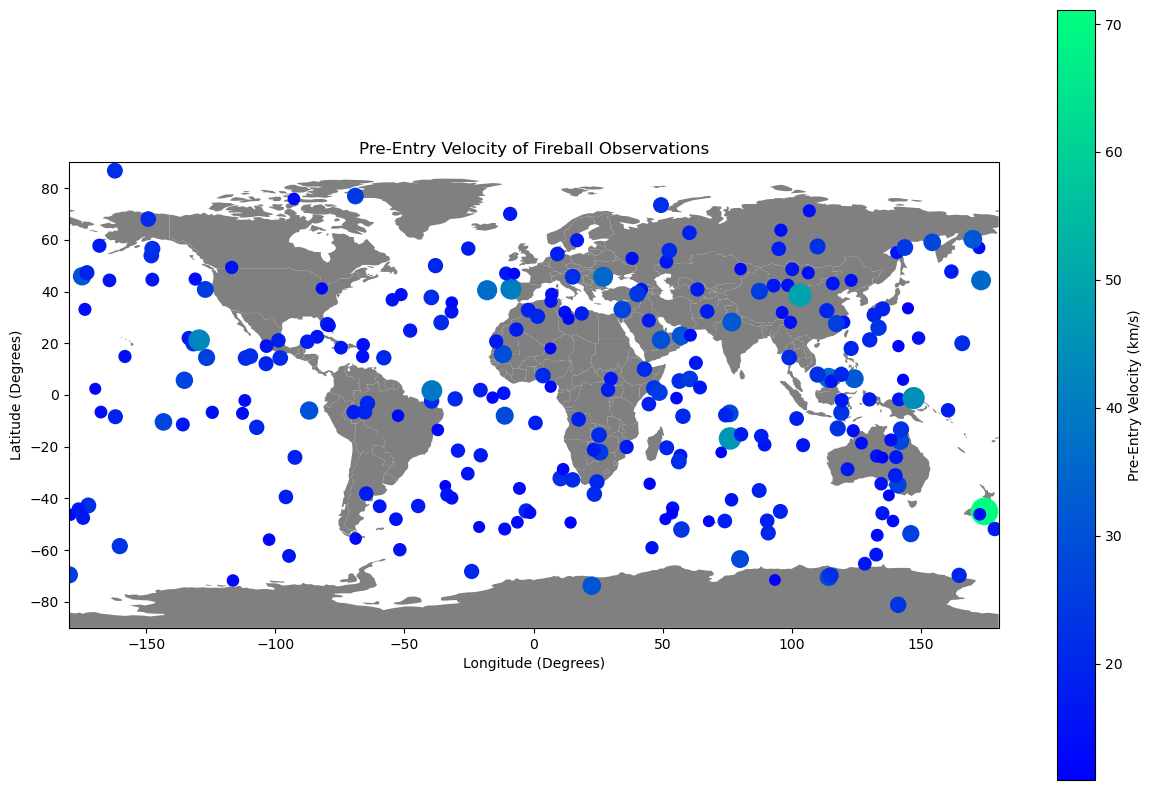

In [10]:
# retrieve world map from GeoPandas
world_map = geopandas.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# Set up world map plot
fig, ax = plt.subplots(figsize=(15, 10))
world_map.plot(color="grey", ax=ax)

# Plot Fireball Locations with Velocity
x = fireball_df["longitude"]
y = fireball_df["latitude"]
z = fireball_df["velocity"]
plt.scatter(x, y, s=5*z, c=z, cmap="winter")
plt.colorbar(label="Pre-Entry Velocity (km/s)")

# Setup Axis Limits and Title/Labels
plt.xlim([-180, 180])
plt.ylim([-90, 90])
plt.title("Pre-Entry Velocity of Fireball Observations")
plt.xlabel("Longitude (Degrees)")
plt.ylabel("Latitude (Degrees)")
plt.show()

### Plot the Altitude of Fireballs

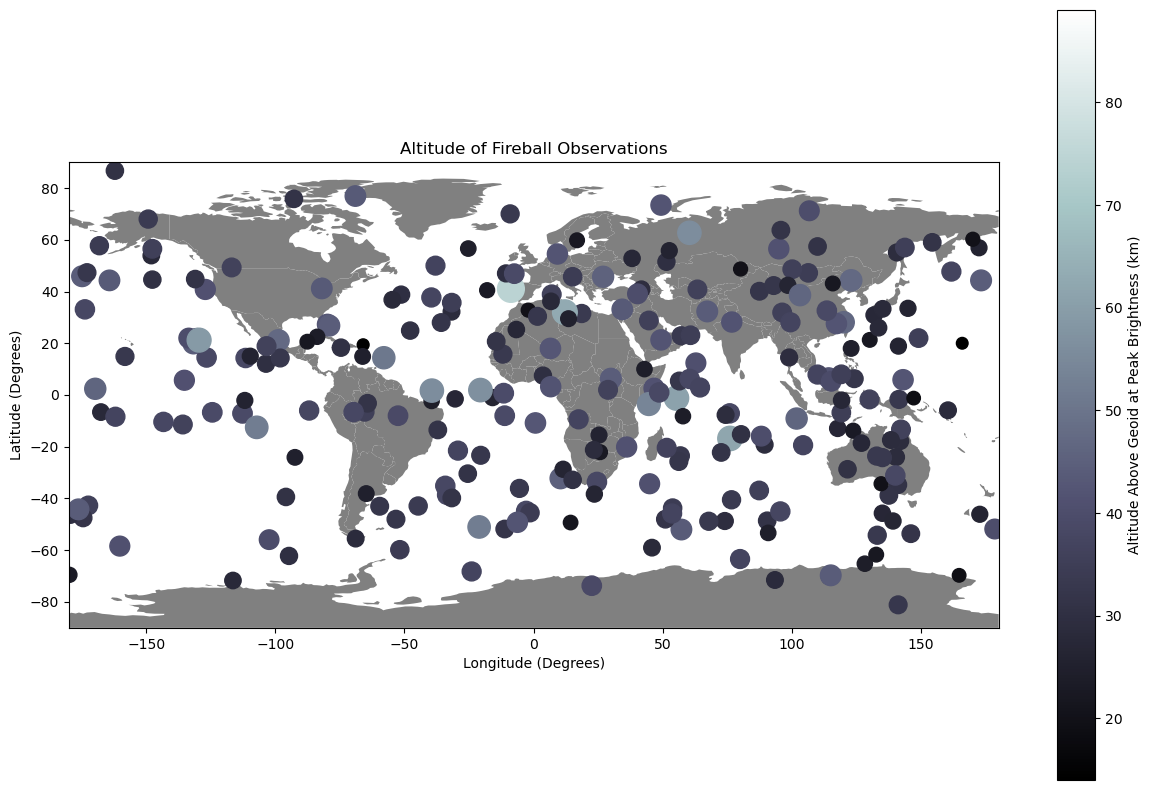

In [11]:
# retrieve world map from GeoPandas
world_map = geopandas.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# Set up world map plot
fig, ax = plt.subplots(figsize=(15, 10))
world_map.plot(color="grey", ax=ax)

# Plot Fireball Locations with Energy
x = fireball_df["longitude"]
y = fireball_df["latitude"]
z = fireball_df["altitude"]
plt.scatter(x, y, s=5*z, c=z, cmap="bone")
plt.colorbar(label="Altitude Above Geoid at Peak Brightness (km)")

# Setup Axis Limits and Title/Labels
plt.xlim([-180, 180])
plt.ylim([-90, 90])
plt.title("Altitude of Fireball Observations")
plt.xlabel("Longitude (Degrees)")
plt.ylabel("Latitude (Degrees)")
plt.show()

---

## Resources and references

 - More information about [plotting a world map with GeoPandas](https://medium.com/@kavee625/plotting-data-on-the-world-map-with-geopandas-f03742615196)